In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy
import os
from scipy.stats import zscore

In [2]:
# set output directory
os.chdir("/ix/djishnu/Aaron_F/GATA2_paper/Results/SuppFig3b")

In [4]:
# load data
data = pd.read_csv('/ix/djishnu/Aaron_F/GATA2_paper/Data/heatmaps/20250117_deseq2_normalized_RNAseq_counts_exp1_removedSamples.csv', index_col=0)
print(data.shape)

# load degs
gata2_degs = np.loadtxt("/ix/djishnu/Aaron_F/GATA2_paper/Data/heatmaps/WT_vs_GATA2_DEGs_LFC_None_and_padj_0.05.txt", dtype=str).tolist()
print(f"GATA2 DEGs: {len(set(gata2_degs))}")

il33_degs = np.loadtxt("/ix/djishnu/Aaron_F/GATA2_paper/Data/heatmaps/Unstim_vs_IL33_DEGs_LFC_1.5_and_padj_0.05.txt", dtype=str).tolist()
print(f"IL33 DEGs: {len(set(il33_degs))}")


(25239, 14)
GATA2 DEGs: 443
IL33 DEGs: 2038


## GATA2 DEGs that are NOT IL33 DEGs

In [5]:
gata2_degs = [deg for deg in gata2_degs if deg not in il33_degs]
len(gata2_degs)

191

In [6]:
file = "GATA2_DEGs_not_IL33_DEGs.txt"
with open(file, "w") as f:
    for ele in gata2_degs:
        f.write(f"{ele}\n")

In [7]:
# make data coef specifc
deg_data = data.loc[gata2_degs]
deg_data

,Unstim_GATA2_0_Exp1_Rep3,IL33_WT_24_Exp1_Rep1,IL33_WT_24_Exp1_Rep2,IL33_GATA2_24_Exp1_Rep3,IL33_GATA2_24_Exp1_Rep4,IL33_GATA2_24_Exp1_Rep5,IL33_GATA2_24_Exp1_Rep6,Unstim_WT_0_Exp1_Rep1,Unstim_WT_0_Exp1_Rep2,Unstim_WT_0_Exp1_Rep3,Unstim_WT_0_Exp1_Rep4,Unstim_WT_0_Exp1_Rep5,Unstim_GATA2_0_Exp1_Rep1,Unstim_GATA2_0_Exp1_Rep2
Lyz1,693.911294,323.401017,265.510372,548.132551,658.454116,853.658084,517.745018,331.227614,348.036837,299.375270,334.258710,390.462730,1121.718624,760.104028
Cdv3,3353.299079,3680.049211,3769.092896,4576.906805,4454.782674,4756.961168,4739.809107,3263.803810,3345.994437,3363.468295,3417.989649,3360.699118,3403.541680,3225.012803
Dck,1811.677654,1811.409066,1763.335191,2542.290977,2818.864776,2493.069631,2443.170358,1492.947881,1480.617144,1652.139744,1574.902668,1733.771077,1532.873283,1825.606995
Slc25a35,128.367534,165.334228,156.805039,86.135115,90.821257,82.455610,76.196437,126.028068,116.846900,116.661996,125.152680,112.670837,87.860850,86.869032
Sf3a3,1422.942007,1308.138944,1394.891450,1704.431220,1717.657030,1955.895581,1840.437007,1228.773662,1283.646656,1348.475429,1277.956557,1325.824941,1324.736900,1381.760536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Hells,439.598254,318.858868,261.662396,428.065421,499.516916,367.412499,400.519731,436.251004,390.602493,365.426548,331.149327,297.217899,335.236060,418.057215
Rps6ka1,6877.351199,6060.135345,6357.819028,5457.834120,5509.444526,4598.112860,5092.461846,7066.458397,7499.067102,6652.307224,6878.733319,6899.146195,7405.901972,6877.584122
Med16,813.801727,1049.236445,961.994103,775.216037,804.903394,721.486591,802.016339,970.254548,1100.864720,856.093180,804.552942,918.850106,882.873594,813.039844
H6pd,1740.227800,1770.529724,1890.318413,1468.212191,1425.893741,931.263364,1372.512736,1557.577660,1953.847088,1441.118780,1688.395160,1685.206061,1746.980792,1569.071886


In [8]:
# Sort columns alphanumerically
sorted_columns = sorted(deg_data.columns)
print(sorted_columns)

['IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6', 'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5']


In [9]:
# resort based on prefered order (can use print statement above for ease)
# sorted_columns = ['Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
#                   'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
#                   'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
#                   'IL33_GATA2_24_Exp1_Rep1', 'IL33_GATA2_24_Exp1_Rep2', 'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6']

# sorted_columns = ['Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
# 'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3', 'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
# 'IL33_GATA2_24_Exp1_Rep1', 'IL33_GATA2_24_Exp1_Rep2', 'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6']

# # WT vs GATA2, all samples
# sorted_columns = [
#     'Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
#     'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
#     'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
#     'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6'
# ]

sorted_columns = [
    'Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
    'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
    'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
    'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6'
]

# unstim_WT vs Unstim_GATA2:
# sorted_columns = [
#     'Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
#     'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
# ]

# IL33_WT vs IL33_GATA2:
# sorted_columns = [
#     'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
#     'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6'
# ]

# sorted_columns = ['Unstim_WT_0_Exp2_Rep1', 'Unstim_WT_0_Exp2_Rep2', 'Unstim_WT_0_Exp2_Rep3', 'Unstim_WT_0_Exp2_Rep4', 'Unstim_WT_0_Exp2_Rep5',
#                   'Unstim_GATA2_0_Exp2_Rep1', 'Unstim_GATA2_0_Exp2_Rep2', 'Unstim_GATA2_0_Exp2_Rep3',
#                   'Staph_WT_24_Exp2_Rep1', 'Staph_WT_24_Exp2_Rep2', 'Staph_WT_24_Exp2_Rep3', 'Staph_WT_24_Exp2_Rep4', 'Staph_WT_24_Exp2_Rep5', 'Staph_WT_24_Exp2_Rep6',
#                   'Staph_GATA2_24_Exp2_Rep1', 'Staph_GATA2_24_Exp2_Rep3']

# # Unstim_WT vs Unstim_GATA2:
# sorted_columns = [
#     'Unstim_WT_0_Exp2_Rep1', 'Unstim_WT_0_Exp2_Rep2', 'Unstim_WT_0_Exp2_Rep3', 'Unstim_WT_0_Exp2_Rep4',
#     'Unstim_GATA2_0_Exp2_Rep1', 'Unstim_GATA2_0_Exp2_Rep2', 'Unstim_GATA2_0_Exp2_Rep3'
# ]

# Staph_WT vs Staph_GATA2:
# sorted_columns = [
#     'Staph_WT_24_Exp2_Rep1', 'Staph_WT_24_Exp2_Rep2', 'Staph_WT_24_Exp2_Rep3', 'Staph_WT_24_Exp2_Rep4', 'Staph_WT_24_Exp2_Rep5',
#     'Staph_GATA2_24_Exp2_Rep1', 'Staph_GATA2_24_Exp2_Rep3'
# ]

# sorted_columns = ['Unstim_WT_0_Exp2_Rep1', 'Unstim_WT_0_Exp2_Rep2', 'Unstim_WT_0_Exp2_Rep3', 'Unstim_WT_0_Exp2_Rep4', 'Unstim_WT_0_Exp2_Rep5',
#                   'Staph_WT_24_Exp2_Rep1', 'Staph_WT_24_Exp2_Rep2', 'Staph_WT_24_Exp2_Rep3', 'Staph_WT_24_Exp2_Rep4', 'Staph_WT_24_Exp2_Rep5', 'Staph_WT_24_Exp2_Rep6',
#                   'Unstim_GATA2_0_Exp2_Rep1', 'Unstim_GATA2_0_Exp2_Rep2', 'Unstim_GATA2_0_Exp2_Rep3',
#                   'Staph_GATA2_24_Exp2_Rep1', 'Staph_GATA2_24_Exp2_Rep3']

# sorted_columns = ['Unstim_WT_0_Exp1_Rep1', 'Unstim_WT_0_Exp1_Rep2', 'Unstim_WT_0_Exp1_Rep3', 'Unstim_WT_0_Exp1_Rep4', 'Unstim_WT_0_Exp1_Rep5',
#                   'Unstim_GATA2_0_Exp1_Rep1', 'Unstim_GATA2_0_Exp1_Rep2', 'Unstim_GATA2_0_Exp1_Rep3',
#                   'IL33_WT_24_Exp1_Rep1', 'IL33_WT_24_Exp1_Rep2',
#                   'IL33_GATA2_24_Exp1_Rep1', 'IL33_GATA2_24_Exp1_Rep2', 'IL33_GATA2_24_Exp1_Rep3', 'IL33_GATA2_24_Exp1_Rep4', 'IL33_GATA2_24_Exp1_Rep5', 'IL33_GATA2_24_Exp1_Rep6',
#                   'Unstim_WT_0_Exp2_Rep1', 'Unstim_WT_0_Exp2_Rep2', 'Unstim_WT_0_Exp2_Rep3', 'Unstim_WT_0_Exp2_Rep4', 'Unstim_WT_0_Exp2_Rep5',
#                   'Unstim_GATA2_0_Exp2_Rep1', 'Unstim_GATA2_0_Exp2_Rep2', 'Unstim_GATA2_0_Exp2_Rep3',
#                   'Staph_WT_24_Exp2_Rep1', 'Staph_WT_24_Exp2_Rep2', 'Staph_WT_24_Exp2_Rep3', 'Staph_WT_24_Exp2_Rep4', 'Staph_WT_24_Exp2_Rep5', 'Staph_WT_24_Exp2_Rep6',
#                   'Staph_GATA2_24_Exp2_Rep1', 'Staph_GATA2_24_Exp2_Rep3']

In [10]:
# average replicates:
df = deg_data.copy()
# Extract replicate group names by removing the "RepX" part
df_grouped = df.T
df_grouped.index = df_grouped.index.str.rsplit("_", n=1).str[0]  # Remove last part (RepX)

# Compute the mean for each replicate group
df_avg = df_grouped.groupby(df_grouped.index).mean()

# Reset index and transpose back to original format
df_avg = df_avg.T

df_avg

,IL33_GATA2_24_Exp1,IL33_WT_24_Exp1,Unstim_GATA2_0_Exp1,Unstim_WT_0_Exp1
Lyz1,644.497442,294.455695,858.577982,340.672232
Cdv3,4632.114939,3724.571053,3327.284521,3350.391062
Dck,2574.348935,1787.372128,1723.385977,1586.875703
Slc25a35,83.902105,161.069633,101.032472,119.472096
Sf3a3,1804.605209,1351.515197,1376.479814,1292.935449
...,...,...,...,...
Hells,423.878642,290.260632,397.630510,364.129454
Rps6ka1,5164.463338,6208.977187,7053.612431,6999.142447
Med16,775.905590,1005.615274,836.571721,930.123099
H6pd,1299.470508,1830.424068,1685.426826,1665.228950


In [11]:
df_avg.columns = ["GATA2 IL33", "WT IL33", "GATA2 PBS", "WT PBS"]

In [12]:
df_avg = df_avg.iloc[:,[3, 2, 1, 0]]
df_avg

,WT PBS,GATA2 PBS,WT IL33,GATA2 IL33
Lyz1,340.672232,858.577982,294.455695,644.497442
Cdv3,3350.391062,3327.284521,3724.571053,4632.114939
Dck,1586.875703,1723.385977,1787.372128,2574.348935
Slc25a35,119.472096,101.032472,161.069633,83.902105
Sf3a3,1292.935449,1376.479814,1351.515197,1804.605209
...,...,...,...,...
Hells,364.129454,397.630510,290.260632,423.878642
Rps6ka1,6999.142447,7053.612431,6208.977187,5164.463338
Med16,930.123099,836.571721,1005.615274,775.905590
H6pd,1665.228950,1685.426826,1830.424068,1299.470508


In [13]:
# get rid of Cre related genes Lyz1 and Lyz2
df_avg = df_avg[~df_avg.index.isin(["Lyz1", "Lyz2"])]
df_avg

,WT PBS,GATA2 PBS,WT IL33,GATA2 IL33
Cdv3,3350.391062,3327.284521,3724.571053,4632.114939
Dck,1586.875703,1723.385977,1787.372128,2574.348935
Slc25a35,119.472096,101.032472,161.069633,83.902105
Sf3a3,1292.935449,1376.479814,1351.515197,1804.605209
Tfec,4889.320617,4977.393312,4857.092447,6797.796092
...,...,...,...,...
Hells,364.129454,397.630510,290.260632,423.878642
Rps6ka1,6999.142447,7053.612431,6208.977187,5164.463338
Med16,930.123099,836.571721,1005.615274,775.905590
H6pd,1665.228950,1685.426826,1830.424068,1299.470508


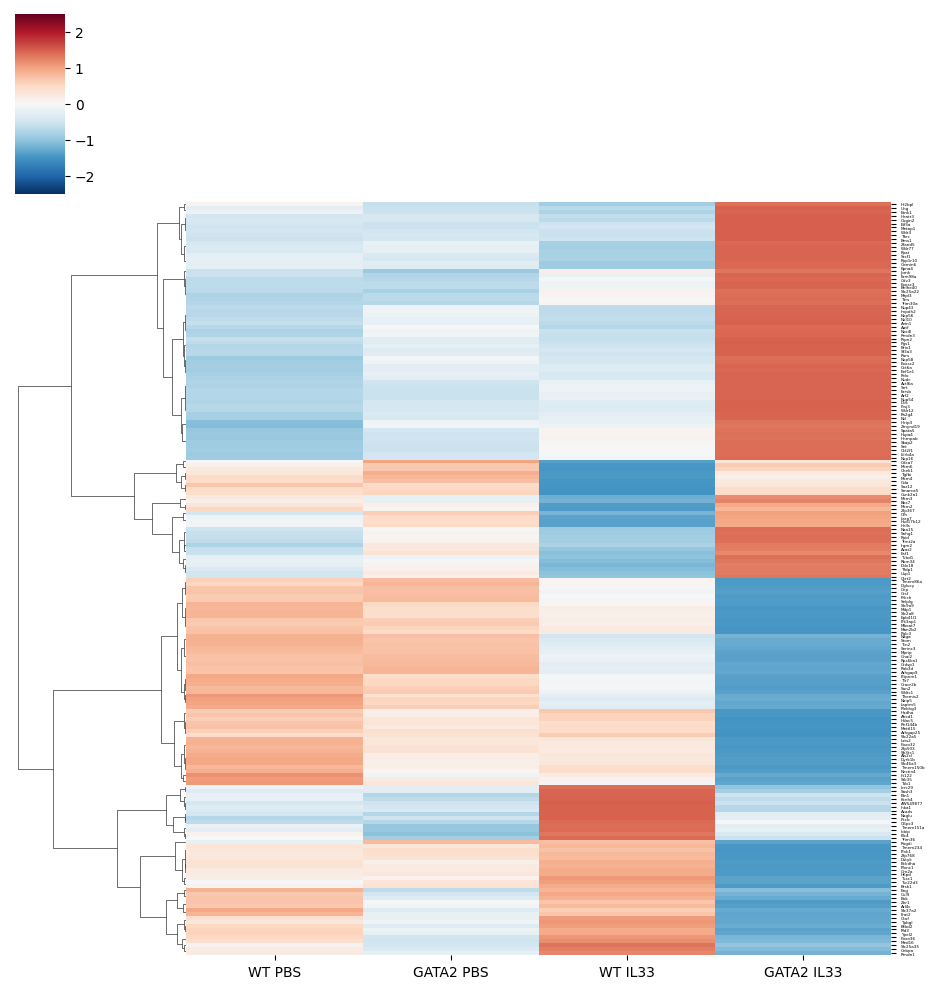

In [14]:
# heatmap
# Create a color vector (black for genes in list, white otherwise)
# row_colors = df_avg.index.to_series().apply(lambda x: 'black' if x in gata2_degs else 'white')
c = sns.color_palette("RdBu_r", as_cmap=True)
cluster_heatmap = sns.clustermap(df_avg, metric='correlation', method='complete', cmap=c,
                                 z_score=0, col_cluster=False, row_cluster=True,
                                 vmin=-2.5, vmax=2.5, yticklabels=True)
# Make y-tick labels smaller
cluster_heatmap.ax_heatmap.set_yticklabels(
    cluster_heatmap.ax_heatmap.get_yticklabels(),
    fontsize=3  # <-- adjust this number
)

# Save and show the heatmap
plt.savefig('GATA2_DEGs_not_IL33_DEGs_avgExp_heatmap.pdf', format='pdf')
plt.show()